In [1]:
import pandas as pd
df=pd.read_csv("C:/Users/Ganesh/Downloads/retail_business_dataset_10000.csv")
df.head()

,OrderID,CustomerID,Region,Category,Sales,Quantity,Profit,OrderDate
0,1,4174,East,Office Supplies,4855.66,4,680.88,2024-01-14
1,2,4507,South,Electronics,4895.86,5,1380.81,2024-09-02
2,3,1860,North,Furniture,738.09,3,1312.95,2024-02-15
3,4,2294,South,Furniture,609.28,6,1363.36,2025-09-16
4,5,2130,East,Office Supplies,2122.31,3,1442.90,2025-07-08


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   OrderID     10000 non-null  int64  
 1   CustomerID  10000 non-null  int64  
 2   Region      10000 non-null  object 
 3   Category    10000 non-null  object 
 4   Sales       10000 non-null  float64
 5   Quantity    10000 non-null  int64  
 6   Profit      10000 non-null  float64
 7   OrderDate   10000 non-null  object 
dtypes: float64(2), int64(3), object(3)
memory usage: 625.1+ KB


In [3]:
df.isnull().sum()


OrderID       0
CustomerID    0
Region        0
Category      0
Sales         0
Quantity      0
Profit        0
OrderDate     0
dtype: int64

In [4]:
df.isnull().mean()

OrderID       0.0
CustomerID    0.0
Region        0.0
Category      0.0
Sales         0.0
Quantity      0.0
Profit        0.0
OrderDate     0.0
dtype: float64

In [5]:
df.describe()

,OrderID,CustomerID,Sales,Quantity,Profit
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,3010.561100,2546.826920,5.053500,652.992541
std,2886.89568,1152.371939,1418.782569,2.570311,491.750694
min,1.00000,1000.000000,100.050000,1.000000,-199.840000
25%,2500.75000,2001.750000,1315.620000,3.000000,230.010000
50%,5000.50000,3004.000000,2541.110000,5.000000,649.705000
75%,7500.25000,4010.000000,3774.232500,7.000000,1083.827500
max,10000.00000,4999.000000,4999.470000,9.000000,1499.830000


In [6]:
df.groupby("Region")["Sales"].sum()

Region
East     6222090.92
North    6569303.59
South    6348764.57
West     6328110.12
Name: Sales, dtype: float64

In [7]:
df.groupby("Category")["Profit"].sum()

Category
Electronics        2162754.28
Furniture          2187891.94
Office Supplies    2179279.19
Name: Profit, dtype: float64

In [8]:
df.groupby("CustomerID")["Sales"].sum().sort_values(ascending=False).head(10)

CustomerID
3708    33756.65
4854    31332.39
3994    27832.89
1972    27247.75
1018    26317.57
2629    24829.00
4896    24300.33
1661    23973.28
2016    23957.62
3300    23841.02
Name: Sales, dtype: float64

In [10]:
df[["Sales","Quantity","Profit"]].corr()

,Sales,Quantity,Profit
Sales,1.000000,-0.004631,0.020837
Quantity,-0.004631,1.000000,-0.010691
Profit,0.020837,-0.010691,1.000000


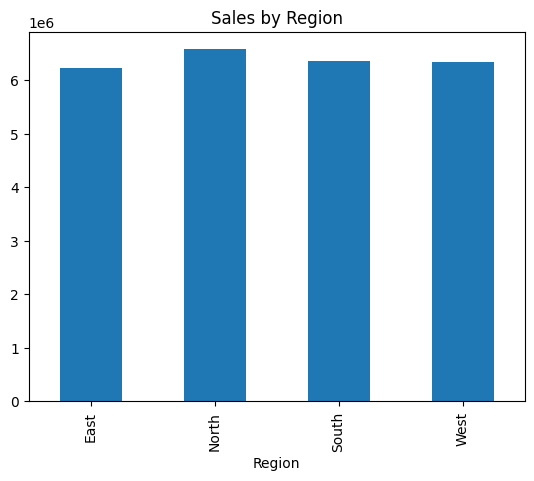

In [11]:
import matplotlib.pyplot as plt
df.groupby("Region")["Sales"].sum().plot(kind="bar")
plt.title("Sales by Region")
plt.show()

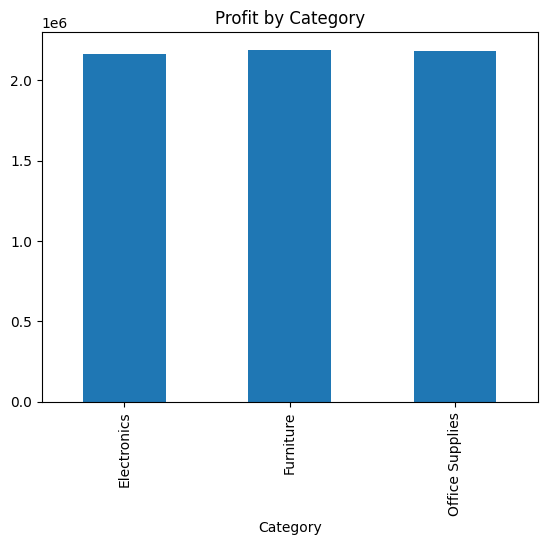

In [12]:
df.groupby("Category")["Profit"].sum().plot(kind="bar")
plt.title("Profit by Category")
plt.show()

In [17]:
monthly_sales = df.groupby(df["OrderDate"].dt.month)["Sales"].sum()

monthly_sales.plot(kind="line", marker="o", figsize=(8, 4))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()

AttributeError: Can only use .dt accessor with datetimelike values

In [18]:
print(df["OrderDate"].dtype)

object


In [20]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

SyntaxError: expression cannot contain assignment, perhaps you meant "=="? (3767604353.py, line 1)

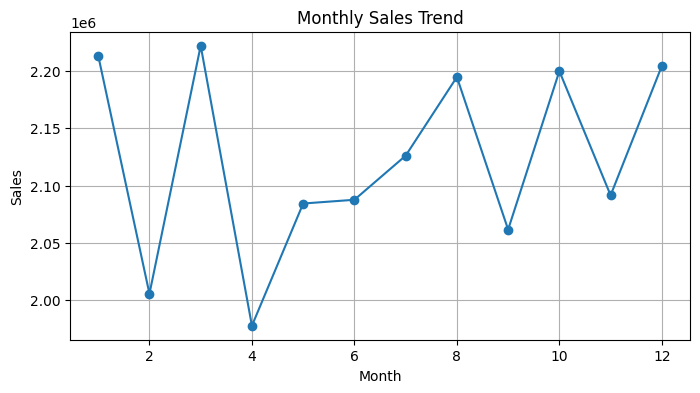

In [21]:
monthly_sales = df.groupby(df["OrderDate"].dt.month)["Sales"].sum()

monthly_sales.plot(kind="line", marker="o", figsize=(8,4))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()